In [1]:
setwd("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/CLR/NEW_CLR/Rounds_v2_CLR_8/Cell_states/Ref_Standard/CM/")

library(stringr) #deal with string
options(stringsAsFactors = FALSE)

# --- Load Libraries without warnings/messages ---
quiet_library <- function(pkg) suppressWarnings(suppressMessages(library(pkg, character.only = TRUE)))

pkgs <- c(
  "dplyr", "zCompositions", "compositions", "reshape2", "ggplot2",
  "ggpubr", "tidyr", "tibble", "stringr", "purrr"
)

invisible(lapply(pkgs, quiet_library))

options(stringsAsFactors = FALSE)
options(future.globals.maxSize = 10 * 1024^3)



In [2]:

# 1. Load configuration variables
metadata_file <- "metadata_for_clr_CM.csv"
sample_col    <- "Sample_ID"
celltype_col  <- "cell_states"
condition_col <- "Condition_subsets"
ref_condition <- "Standard protocol"

# Load metadata (assuming index=False was used in Python)
meta <- read.csv(metadata_file, check.names = FALSE)



In [3]:

# ----------------------------------------------------------------------
# Helper Functions (CLEANED and FIXED)
# ----------------------------------------------------------------------

get.count.matrix <- function(props, celltype_col, value_col) {
  frm <- as.formula(paste("Sample_ID", celltype_col, sep = "~"))
  # Use sum for aggregation of raw counts
  ct <- reshape2::acast(props, frm, value.var = value_col, fun.aggregate = sum, fill = 0) 
  return(ct)
}

# CORRECTED: Includes 'label = 0' argument and logic to handle only rows with zeros
get.proportion.matrix <- function(prop.coarse, celltype_col, pseudocount = 0,
                                  value_col = "proportion", impute_zeros = TRUE,
                                  imputation_method = "cmultRepl") {
    ct <- get.count.matrix(prop.coarse, celltype_col, value_col)
    
    # Ensure matrix is standard numeric/integer type
    ct <- as.matrix(ct)
    
    if (!impute_zeros) {
        ct <- ct + pseudocount
        ct <- ct / rowSums(ct)
    } else {
        if (imputation_method == "cmultRepl") {
            # Identify rows that actually contain a zero count
            rows_to_impute <- rowSums(ct == 0 & !is.na(ct)) > 0
            
            if (any(rows_to_impute)) {
                imputed_rows <- zCompositions::cmultRepl(
                    X = ct[rows_to_impute, ], 
                    method = "GBM", 
                    label = 0 # *** CRUCIAL FIX: Explicitly setting 0 ***
                )
                ct[rows_to_impute, ] <- as.matrix(imputed_rows)
            } else {
                message("Warning: No zero counts found for imputation. Skipping cmultRepl.")
            }
        }
    }
    return(ct)
}

# CORRECTED: Ensures correct factor level ordering for CLR sign
da.by.covariate <- function(ct, celltype, condition_vec, ref_condition = NULL) {
    # ensure intended baseline is the intercept
    if (!is.null(ref_condition) && any(condition_vec == ref_condition)) {
        non_ref <- setdiff(unique(as.character(condition_vec)), ref_condition)
        condition_vec <- factor(condition_vec, levels = c(ref_condition, non_ref))
    } else {
        condition_vec <- factor(condition_vec)
    }

    Z <- compositions::clr(compositions::acomp(ct))
    data <- data.frame(
        abundance  = Z[, celltype],
        proportion = ct[, celltype],
        Condition  = condition_vec
    )

    m  <- lm(abundance  ~ Condition, data = data)
    smr <- t(coef(summary(m))[2, ])

    m2   <- lm(proportion ~ Condition, data = data)
    smr2 <- t(coef(summary(m2))[2, ])
    colnames(smr2) <- paste("prop", colnames(smr2), sep = "_")

    mean.prop       <- mean(data$proportion)
    mean.prop.ref   <- coef(m2)[1] # intercept = reference level

    return(data.frame(smr, smr2, mean.prop, mean.prop.ref, check.names = FALSE))
}


# ----------------------------------------------------------------------
# Data Processing and CLR Analysis Workflow
# ----------------------------------------------------------------------

# 2. Prepare data: Count cell states per sample
prop.coarse <- meta %>%
    # Use rlang::sym() for safe variable passing
    dplyr::group_by(!!rlang::sym(celltype_col), Sample_ID, Condition_subsets) %>%  
    dplyr::summarise(count = dplyr::n(), .groups = "drop")

# 3. Generate matrices
prop_matrix <- get.proportion.matrix(prop.coarse, celltype_col = celltype_col, value_col = "count")
count_matrix <- get.count.matrix(prop.coarse, celltype_col = celltype_col, value_col = "count")

# 4. Create analysis dataframe
analysis_df <- as.data.frame(prop_matrix) %>%
    tibble::rownames_to_column("Sample_ID") %>%
    dplyr::left_join(dplyr::distinct(meta, Sample_ID, Condition_subsets), by = "Sample_ID")

# 5. Get conditions to test
conditions_to_test <- setdiff(unique(analysis_df$Condition_subsets), ref_condition)

# 6. Run analysis loop
all_results <- list()

for (cond in conditions_to_test) {
    selected <- analysis_df %>%
        filter(Condition_subsets %in% c(ref_condition, cond)) %>%
        # Filter for samples with at least 10 cells total 
        filter(Sample_ID %in% rownames(count_matrix)[rowSums(count_matrix) >= 10])

    # Only keep cell state columns
    cell_states <- setdiff(colnames(selected), c("Sample_ID", "Condition_subsets"))

    # Execute DA for each cell state
    results <- lapply(cell_states, function(ct) {
        da.by.covariate(
            selected[, cell_states, drop = FALSE],
            celltype = ct,
            condition_vec = selected$Condition_subsets,
            ref_condition = ref_condition
        )
    })

    results <- do.call(rbind, results)
    rownames(results) <- cell_states
    all_results[[cond]] <- results
}

# 7. Final results processing and FDR calculation
results_df <- purrr::imap_dfr(all_results, ~ {
    data.frame(
        Condition = .y,
        CellType = rownames(.x),
        PValue = .x[,"Pr(>|t|)"],
        EffectSize = .x[,"Estimate"],
        FoldChange = exp(.x[,"Estimate"]),
        MeanPropControl = .x[,"mean.prop.ref"],
        stringsAsFactors = FALSE
    )
}) %>%
    dplyr::group_by(Condition) %>%
    dplyr::mutate(FDR = p.adjust(PValue, method = "BH")) %>%
    dplyr::ungroup()

write.csv(results_df, "clr_cellstates_ref_Standard.csv", row.names = FALSE)


In [17]:
our_fill_scale_gradient2 <- scale_fill_gradient2(
  limits = c(-1, 1),
  # Use the 'squish' transformer to force out-of-bounds values to the limit colors
  oob = scales::squish, 
  high = "#FF6600",   # orange
  mid = "white",
  low = "#6699FF"     # blue
)

flipx45 <- theme(axis.text.x = element_text(angle = 45, hjust = 1))

axis_format <- theme(
  axis.text.x = element_text(face = "bold"),
  axis.text.y = element_text(face = "bold"),
  axis.title.x = element_text(face = "bold"),
  axis.title.y = element_text(face = "bold")
)



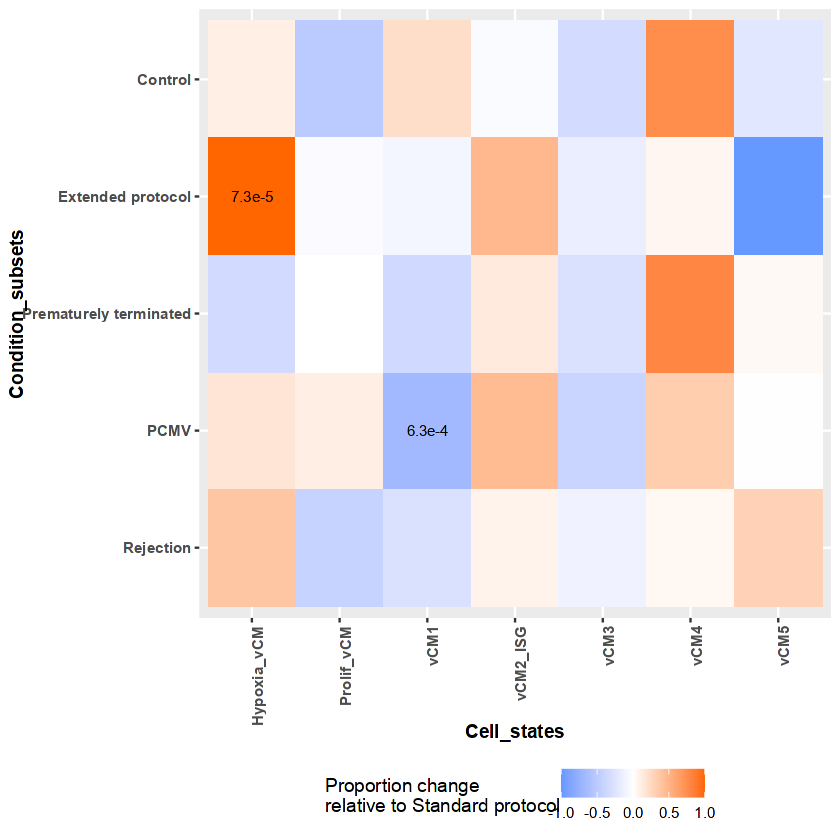

In [19]:

results_df$FDR_plot <- results_df$FDR


# Define the desired order of conditions
condition_order <- c( "Rejection","PCMV", "Prematurely terminated", "Extended protocol", "Control")

# Convert Condition to factor with specified levels before plotting
results_df$Condition <- factor(results_df$Condition, levels = condition_order)

# Now create the plot with the ordered conditions
p1 <- ggplot(results_df, aes(x = CellType, y = Condition, fill = EffectSize)) +
  geom_tile() +
  our_fill_scale_gradient2 +
  labs(
    y = "Condition_subsets",
    x = "Cell_states",
    fill = "Proportion change\nrelative to Standard protocol"
  ) +
  theme(
    legend.position = "bottom",
    axis.text.x = element_text(angle = 90, hjust = 1, face = "bold"),
    axis.text.y = element_text(face = "bold"),
    axis.title.x = element_text(face = "bold"),
    axis.title.y = element_text(face = "bold")
  ) +
  # Add p-value for significant cells only
  geom_text(
    data = subset(results_df, FDR_plot < 0.05),
    aes(label = gsub("e-0", "e-", formatC(PValue, format = "e", digits = 1))),
    color = "black", size = 3
  )

# Save with reduced height
# ggsave("p1_heatmap_plot.pdf", plot = p1, width = 6, height = 4.3, units = "in")

ggsave("heatmap_CM_states_ref_Standard.pdf", plot = p1, width = 6, height = 4.3, units = "in", dpi = 300)
p1




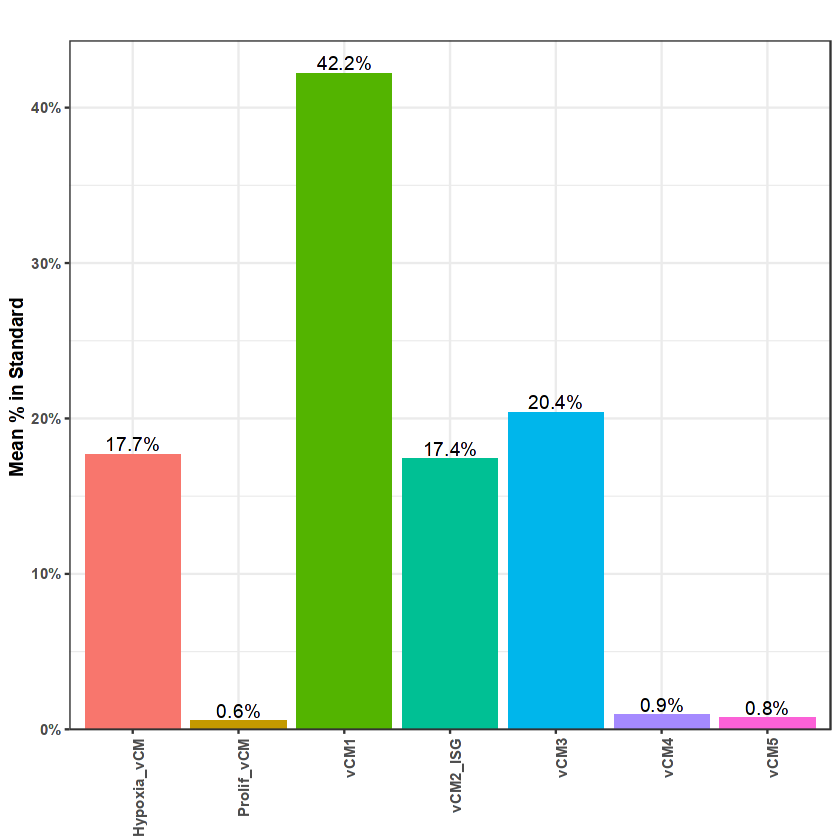

In [30]:
# 1) Convert counts → per-sample proportions
prop_from_counts <- sweep(count_matrix, 1, rowSums(count_matrix), "/")

# 2) Long format with Sample_ID for joining
prop_long <- as.data.frame(prop_from_counts) %>%
  tibble::rownames_to_column("Sample_ID") %>%
  tidyr::pivot_longer(-Sample_ID, names_to = "CellState", values_to = "Prop")

# 3) Keep only the reference samples (Standard protocol)
prop_ref <- prop_long %>%
  dplyr::left_join(dplyr::distinct(meta, Sample_ID, Condition_subsets), by = "Sample_ID") %>%
  dplyr::filter(Condition_subsets == ref_condition)

# 4) Mean proportion per cell state within the reference group
ref_means <- prop_ref %>%
  dplyr::group_by(CellState) %>%
  dplyr::summarise(MeanProp = mean(Prop, na.rm = TRUE), .groups = "drop")

# 5) Barplot (no manual ordering)
p_ref <- ggplot(ref_means, aes(x = CellState, y = MeanProp, fill = CellState)) +
  geom_col() +
  geom_text(aes(label = scales::percent(MeanProp, accuracy = 0.1)),
            vjust = -0.2, size = 4) +
  labs(title = "",
       y = "Mean % in Standard ",
       x = "Cell state") +
  theme_bw() +
  theme(
    axis.text.x  = element_text(angle = 90, hjust = 1, face = "bold"),
    axis.text.y  = element_text(face = "bold"),
    axis.title.x = element_blank(),
    axis.title.y = element_text(face = "bold"),
    legend.position = "none"
  ) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1),
                     expand = expansion(mult = c(0, 0.05))) +
  scale_x_discrete(drop = FALSE)

ggsave("barplot_CM_states_ref_Standard.pdf",
       plot = p_ref, width = 6, height = 4, units = "in", dpi = 300)
p_ref


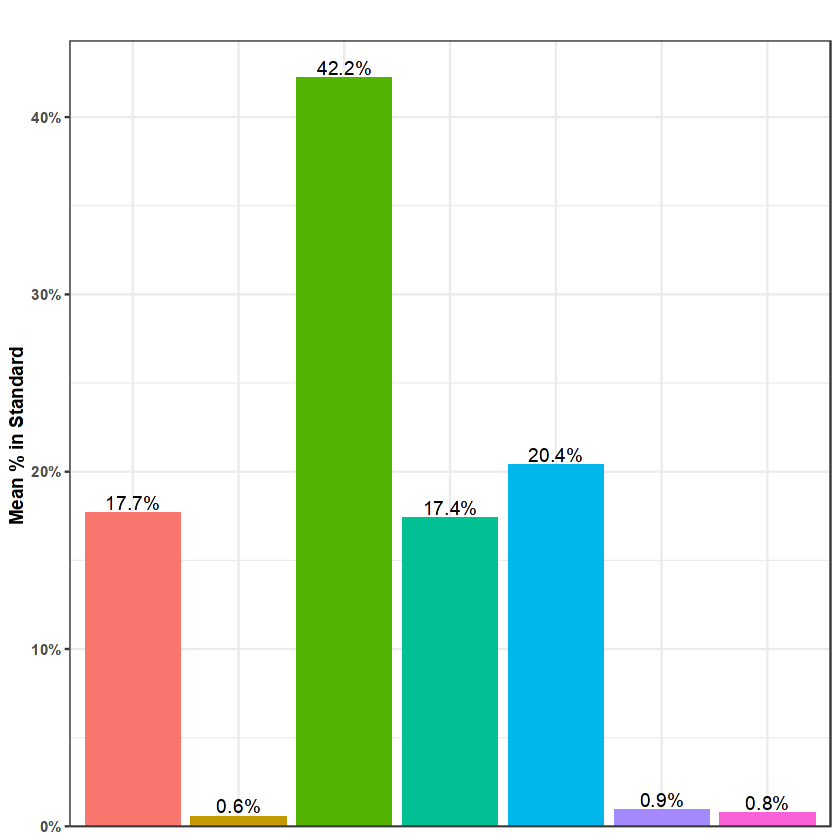

In [31]:

# 5) Barplot (X-Axis REMOVED)
p_ref_no_x_axis <- ggplot(ref_means, aes(x = CellState, y = MeanProp, fill = CellState)) +
    geom_col() +
    geom_text(aes(label = scales::percent(MeanProp, accuracy = 0.1)),
              vjust = -0.2, size = 4) +
    labs(title = "",
         y = "Mean % in Standard ",
         # x is set to "Cell state" but will be removed by theme
         x = "Cell state") + 
    theme_bw() +
    theme(
        # --- CHANGES TO REMOVE X-AXIS ELEMENTS ---
        axis.title.x = element_blank(), # Remove X-axis title
        axis.text.x  = element_blank(), # Remove X-axis labels (writings)
        axis.ticks.x = element_blank(), # Remove X-axis ticks
        # ----------------------------------------
        
        axis.text.y  = element_text(face = "bold"),
        axis.title.y = element_text(face = "bold"),
        legend.position = "none"
    ) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1),
                       expand = expansion(mult = c(0, 0.05))) +
    scale_x_discrete(drop = FALSE)

ggsave("barplot_CM_states_ref_Standard_no_x_axis.pdf",
       plot = p_ref_no_x_axis, width = 6, height = 4, units = "in", dpi = 300)

print(p_ref_no_x_axis)

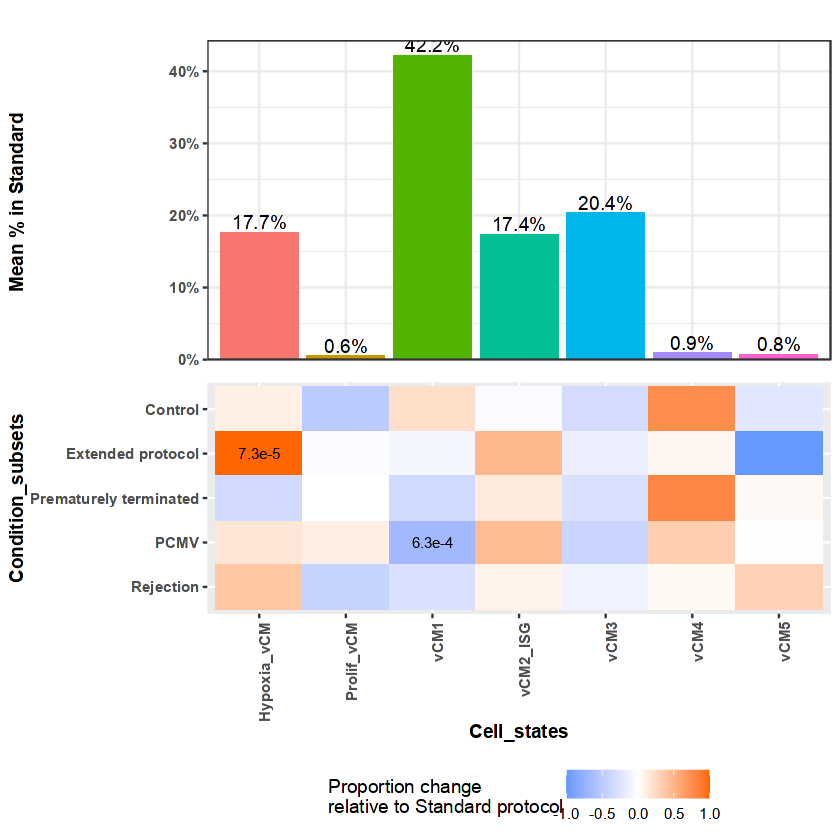

In [34]:
# Merge
plot_all <- ggarrange(
  p_ref_no_x_axis, p1,
  ncol = 1, nrow = 2,
  align = "v",
  heights = c(4, 5)  # You can adjust these numbers for desired proportions
)

# Print in RStudio/viewer
plot_all

# Save as PDF
ggsave("Final_CLR_CM_Standard.pdf", plot = plot_all,
       width = 7, height = 8, units = "in", dpi = 400)
